In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install segmentation-models-pytorch

In [3]:
import numpy as np
import pandas as pd
import rasterio
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
# Training hyperparameters (easy to modify)
BATCH_SIZE = 8
NUM_WORKERS = 2
LR = 1e-4
NUM_EPOCHS = 100
EARLY_STOPPING_PATIENCE = None  # set to None to disable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Device: cuda
Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [6]:
DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")

IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [7]:
NUM_CHANNELS = 12
NORM_CHANNELS = [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]
EXCLUDE_FROM_NORM = [7, 10]  # QA Band, WorldCover

assert len(NORM_CHANNELS) + len(EXCLUDE_FROM_NORM) == NUM_CHANNELS

print("Channels to normalize:", NORM_CHANNELS)
print("Channels excluded from normalization:", EXCLUDE_FROM_NORM)

Channels to normalize: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]
Channels excluded from normalization: [7, 10]


In [8]:
pairs = []
for image_path in sorted(IMAGES_DIR.glob("*.tif")):
    label_path = LABELS_DIR / f"{image_path.stem}.png"
    if label_path.exists():
        pairs.append((image_path, label_path))

print("Total image-mask pairs:", len(pairs))

Total image-mask pairs: 306


In [9]:
def has_water(label_path):
    with rasterio.open(label_path) as src:
        mask = src.read(1)
    return int(np.any(mask == 1))

strat_labels = np.array([has_water(lbl) for _, lbl in pairs])
print("Images with water:", int(np.sum(strat_labels == 1)))
print("Images without water:", int(np.sum(strat_labels == 0)))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Images with water: 261
Images without water: 45


In [11]:
total_water = 0
total_bg = 0
for _, lbl in pairs:
    with rasterio.open(lbl) as src:
        m = src.read(1)
        total_water += int((m == 1).sum())
        total_bg    += int((m == 0).sum())

total_px = total_water + total_bg
pos_weight_value = total_bg / max(total_water, 1)

print(f"Water pixels:      {total_water} ({total_water/total_px*100:.2f}%)")
print(f"Background pixels: {total_bg} ({total_bg/total_px*100:.2f}%)")
print(f"pos_weight:        {pos_weight_value:.4f}")

Water pixels:      1302272 (25.98%)
Background pixels: 3711232 (74.02%)
pos_weight:        2.8498


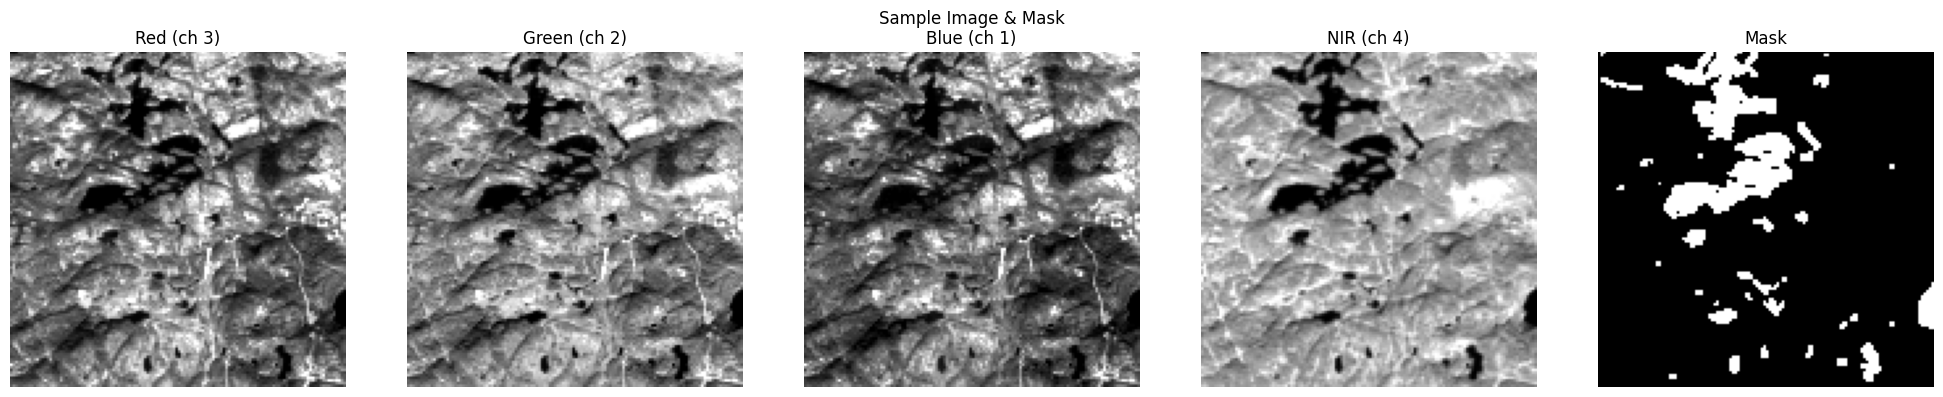

In [12]:
# Visualize a sample image (RGB + NIR) and its mask
img_path, msk_path = pairs[0]
with rasterio.open(img_path) as src:
    img_raw = src.read().astype(np.float32)
with rasterio.open(msk_path) as src:
    msk_raw = src.read(1)

show_channels = [3, 2, 1, 4]
names = ["Red (ch 3)", "Green (ch 2)", "Blue (ch 1)", "NIR (ch 4)"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, ch, name in zip(axes[:4], show_channels, names):
    band = img_raw[ch]
    vmin, vmax = np.percentile(band, (2, 98))
    ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.axis("off")
axes[4].imshow(msk_raw, cmap="gray")
axes[4].set_title("Mask")
axes[4].axis("off")
plt.suptitle("Sample Image & Mask")
plt.tight_layout()
plt.show()

In [13]:
train_pairs, temp_pairs, train_labels, temp_labels = train_test_split(
    pairs, strat_labels, test_size=0.30, random_state=SEED, stratify=strat_labels
)
val_pairs, test_pairs, val_labels, test_labels = train_test_split(
    temp_pairs, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_pairs)} (water: {int(train_labels.sum())})")
print(f"Val:   {len(val_pairs)} (water: {int(val_labels.sum())})")
print(f"Test:  {len(test_pairs)} (water: {int(test_labels.sum())})")

Train: 214 (water: 183)
Val:   46 (water: 39)
Test:  46 (water: 39)


In [14]:
def compute_channel_stats(pairs, norm_channels):
    n_ch = len(norm_channels)
    sums = np.zeros(n_ch, dtype=np.float64)
    sums_sq = np.zeros(n_ch, dtype=np.float64)
    n_pixels = 0

    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)  # (12, H, W)
        img_norm = img[norm_channels]
        img_norm = np.nan_to_num(img_norm, nan=0.0, posinf=0.0, neginf=0.0)
        flat = img_norm.reshape(n_ch, -1)
        sums += flat.sum(axis=1)
        sums_sq += (flat ** 2).sum(axis=1)
        n_pixels += flat.shape[1]

    mean = sums / n_pixels
    var = sums_sq / n_pixels - mean ** 2
    var = np.clip(var, 1e-12, None)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)

train_mean, train_std = compute_channel_stats(train_pairs, NORM_CHANNELS)
print("Train Mean (10 channels):\n", train_mean)
print("\nTrain Std (10 channels):\n", train_std)

# Save stats
stats = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "norm_channels": NORM_CHANNELS,
    "exclude_from_norm": EXCLUDE_FROM_NORM,
    "num_channels": NUM_CHANNELS,
}
with open(DATASET_DIR / "train_channel_stats.json", "w") as f:
    json.dump(stats, f, indent=4)
print("\nSaved:", DATASET_DIR / "train_channel_stats.json")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Train Mean (10 channels):
 [ 394.15018   492.13864   820.9418    973.08264  2069.7773   1948.11
 1336.509     123.91796   294.36536    10.063989]

Train Std (10 channels):
 [ 261.87573   310.67526   396.09274   567.03094  1070.1465   1196.9388
  953.8549   1394.3047    456.21017    28.180136]

Saved: /content/drive/MyDrive/Cellula/WaterSegmentation/data/train_channel_stats.json


In [15]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std, norm_channels=NORM_CHANNELS, augment=False):
        super().__init__()
        self.pairs = pairs
        self.norm_channels = list(norm_channels)
        self.augment = augment
        self.mean = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std  = torch.tensor(std,  dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)  # (12, H, W)
        image = torch.from_numpy(image)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)

        # Normalization on NORM_CHANNELS only
        image_norm = image[self.norm_channels]
        image_norm = (image_norm - self.mean) / self.std
        image_out = image.clone()
        image_out[self.norm_channels] = image_norm

        # Augmentation (train only)
        if self.augment:
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[2]).clone()
                mask = torch.flip(mask, dims=[2]).clone()
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[1]).clone()
                mask = torch.flip(mask, dims=[1]).clone()
            if torch.rand(1).item() > 0.5:
                image_out = torch.rot90(image_out, k=1, dims=[1, 2]).clone()
                mask = torch.rot90(mask, k=1, dims=[1, 2]).clone()
            if torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image_out[self.norm_channels]) * 0.05
                image_out[self.norm_channels] += noise

        return image_out, mask


train_ds = WaterSegDataset(train_pairs, train_mean, train_std, augment=True)
val_ds   = WaterSegDataset(val_pairs,   train_mean, train_std, augment=False)
test_ds  = WaterSegDataset(test_pairs,  train_mean, train_std, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

# Sanity check
images, masks = next(iter(train_loader))
print("Images shape:", images.shape, "| dtype:", images.dtype)
print("Masks shape: ", masks.shape,  "| dtype:", masks.dtype)
print("Unique mask values:", torch.unique(masks))

Train batches: 27
Val batches:   6
Test batches:  6
Images shape: torch.Size([8, 12, 128, 128]) | dtype: torch.float32
Masks shape:  torch.Size([8, 1, 128, 128]) | dtype: torch.float32
Unique mask values: tensor([0., 1.])


In [16]:
# ============================================================
# Strategy 2: Trainable CNN Converter + Pretrained U-Net
# ============================================================

class CNNConverter(nn.Module):
    """
    Learnable 12 -> 3 channel adapter.
    Preserves spatial resolution (no resize / interpolation).
    """
    def __init__(self, in_channels=12, out_channels=3, base_channels=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(base_channels, base_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),

            # Final layer outputs exactly 3 channels. No activation.
            nn.Conv2d(base_channels, out_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class ConverterUNet(nn.Module):
    """
    12-ch input -> CNN converter -> 3-ch pretrained U-Net.
    The ResNet34 encoder still receives 3 channels (ImageNet interface).
    """
    def __init__(self, in_channels=12, num_classes=1, converter_base=32):
        super().__init__()
        self.converter = CNNConverter(
            in_channels=in_channels,
            out_channels=3,
            base_channels=converter_base,
        )
        self.segmenter = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,        # IMPORTANT: keep 3-channel encoder input
            classes=num_classes,
            activation=None,      # logits for BCEWithLogitsLoss
        )

    def forward(self, x):
        x3 = self.converter(x)       # (B, 3, H, W)
        logits = self.segmenter(x3)  # (B, 1, H, W)
        return logits

In [17]:
model = ConverterUNet(
    in_channels=NUM_CHANNELS,
    num_classes=1,
    converter_base=32,
).to(DEVICE)

print("Model parameters:", sum(p.numel() for p in model.parameters()))

first_conv_converter = model.converter.net[0]
first_conv_segmenter = model.segmenter.encoder.conv1

print("\nConverter first conv:", first_conv_converter)
print("Converter output channels:", model.converter.net[-1].out_channels)
print("Segmenter first conv:", first_conv_segmenter)
print("Segmenter in_channels:", first_conv_segmenter.in_channels)

assert model.converter.net[-1].out_channels == 3, "Converter must output 3 channels"
assert first_conv_segmenter.in_channels == 3, "Encoder must receive 3 channels"

# Forward pass test
with torch.no_grad():
    x_test = torch.randn(2, NUM_CHANNELS, 128, 128).to(DEVICE)
    y_test = model(x_test)
print("\nInput shape: ", tuple(x_test.shape))
print("Output shape:", tuple(y_test.shape))
assert x_test.shape == (2, 12, 128, 128)
assert y_test.shape == (2, 1, 128, 128)
print("Forward pass OK.")

Model parameters: 24450036

Converter first conv: Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
Converter output channels: 3
Segmenter first conv: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Segmenter in_channels: 3

Input shape:  (2, 12, 128, 128)
Output shape: (2, 1, 128, 128)
Forward pass OK.


In [18]:
POS_WEIGHT = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

print("\nloss_fn:", loss_fn)
print("optimizer:", optimizer)


loss_fn: BCEWithLogitsLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [19]:
loss_fn = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

In [20]:
# ============================================================
# Sanity check: converter gradients are non-zero and weights update
# ============================================================
model.train()
x_dummy = torch.randn(2, NUM_CHANNELS, 128, 128).to(DEVICE)
y_dummy = torch.randint(0, 2, (2, 1, 128, 128)).float().to(DEVICE)

optimizer.zero_grad()
logits_dummy = model(x_dummy)
loss_dummy = loss_fn(logits_dummy, y_dummy)
loss_dummy.backward()

conv_grad = model.converter.net[0].weight.grad
print("Converter first conv grad norm:",
      None if conv_grad is None else conv_grad.norm().item())

assert conv_grad is not None, "Converter gradient is None!"
assert conv_grad.abs().sum() > 0, "Converter gradients are all zero!"

before = model.converter.net[0].weight.detach().clone()
optimizer.step()
after = model.converter.net[0].weight.detach()

print("Converter weight changed:", not torch.equal(before, after))
assert not torch.equal(before, after), "Converter weights did not update!"
print("Converter is learning. ✅")

Converter first conv grad norm: 6.25696325302124
Converter weight changed: True
Converter is learning. ✅


In [21]:
@torch.no_grad()
def compute_metrics(logits, targets, thr=0.5, eps=1e-7):
    """Compute Water-class metrics with safe division."""
    preds = (torch.sigmoid(logits) > thr).float().view(-1)
    targets = targets.view(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)

    return {"iou": iou, "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy}

In [22]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.detach().cpu())
        targets_all.append(y.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.detach().cpu())
        targets_all.append(y.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics

In [23]:
# ============================================================
# Training
# ============================================================
best_path = DATASET_DIR / "best_converter_unet.pth"
best_val_iou = 0.0
best_epoch = -1
history = []
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_metrics = evaluate(model, val_loader, loss_fn, DEVICE)
    scheduler.step(val_metrics["iou"])

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    print(f"Epoch {epoch:3d} | "
          f"Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | "
          f"IoU {val_metrics['iou']:.4f} | "
          f"F1 {val_metrics['f1']:.4f} | "
          f"Prec {val_metrics['precision']:.4f} | "
          f"Rec {val_metrics['recall']:.4f}")

    # Checkpoint selection on validation IoU (same logic as baseline)
    if val_metrics["iou"] > best_val_iou:
        best_val_iou = val_metrics["iou"]
        best_epoch = epoch
        torch.save(model.state_dict(), best_path)
        print(f"  → New best model saved (Val IoU: {best_val_iou:.4f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if EARLY_STOPPING_PATIENCE is not None and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

print(f"\nBest Val IoU: {best_val_iou:.4f} at epoch {best_epoch}")
print("Best checkpoint:", best_path)

Epoch   1 | Train Loss 0.9816 | Val Loss 0.8643 | IoU 0.3451 | F1 0.5132 | Prec 0.3671 | Rec 0.8520
  → New best model saved (Val IoU: 0.3451)
Epoch   2 | Train Loss 0.7840 | Val Loss 0.7355 | IoU 0.4329 | F1 0.6042 | Prec 0.4814 | Rec 0.8112
  → New best model saved (Val IoU: 0.4329)
Epoch   3 | Train Loss 0.7041 | Val Loss 0.7430 | IoU 0.4731 | F1 0.6423 | Prec 0.5156 | Rec 0.8517
  → New best model saved (Val IoU: 0.4731)
Epoch   4 | Train Loss 0.6718 | Val Loss 0.6100 | IoU 0.5086 | F1 0.6743 | Prec 0.5580 | Rec 0.8519
  → New best model saved (Val IoU: 0.5086)
Epoch   5 | Train Loss 0.5982 | Val Loss 0.5766 | IoU 0.5022 | F1 0.6687 | Prec 0.5632 | Rec 0.8226
Epoch   6 | Train Loss 0.5949 | Val Loss 0.5836 | IoU 0.5131 | F1 0.6782 | Prec 0.6162 | Rec 0.7541
  → New best model saved (Val IoU: 0.5131)
Epoch   7 | Train Loss 0.6214 | Val Loss 0.5572 | IoU 0.4914 | F1 0.6590 | Prec 0.5542 | Rec 0.8125
Epoch   8 | Train Loss 0.5458 | Val Loss 0.5672 | IoU 0.4815 | F1 0.6500 | Prec 0.552

In [24]:
# ================================================================
# Test Evaluation (best model only, evaluated once)
# ================================================================
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

test_loss, test_m = evaluate(model, test_loader, loss_fn, DEVICE)

results_df = pd.DataFrame([{
    "Split": "Test",
    "Loss": round(test_loss, 4),
    "Accuracy": round(test_m["accuracy"], 4),
    "Precision": round(test_m["precision"], 4),
    "Recall": round(test_m["recall"], 4),
    "F1": round(test_m["f1"], 4),
    "IoU": round(test_m["iou"], 4),
}])
print("== Test Results ==")
print(results_df.to_string(index=False))

== Test Results ==
Split   Loss  Accuracy  Precision  Recall     F1    IoU
 Test 0.4293     0.899     0.7531   0.806 0.7787 0.6376


In [25]:
baseline_row = {
    "Model": "Baseline 12-ch pretrained U-Net",
    "Loss": 0.1962,
    "Accuracy": 0.9288,
    "Precision": 0.8827,
    "Recall": 0.7804,
    "F1": 0.8284,
    "IoU": 0.7071,
}

converter_row = {
    "Model": "CNNConverter + 3-ch pretrained U-Net",
    "Loss": round(test_loss, 4),
    "Accuracy": round(test_m["accuracy"], 4),
    "Precision": round(test_m["precision"], 4),
    "Recall": round(test_m["recall"], 4),
    "F1": round(test_m["f1"], 4),
    "IoU": round(test_m["iou"], 4),
}

comparison_df = pd.DataFrame([baseline_row, converter_row])
print(comparison_df.to_string(index=False))

                               Model   Loss  Accuracy  Precision  Recall     F1    IoU
     Baseline 12-ch pretrained U-Net 0.1962    0.9288     0.8827  0.7804 0.8284 0.7071
CNNConverter + 3-ch pretrained U-Net 0.4293    0.8990     0.7531  0.8060 0.7787 0.6376


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


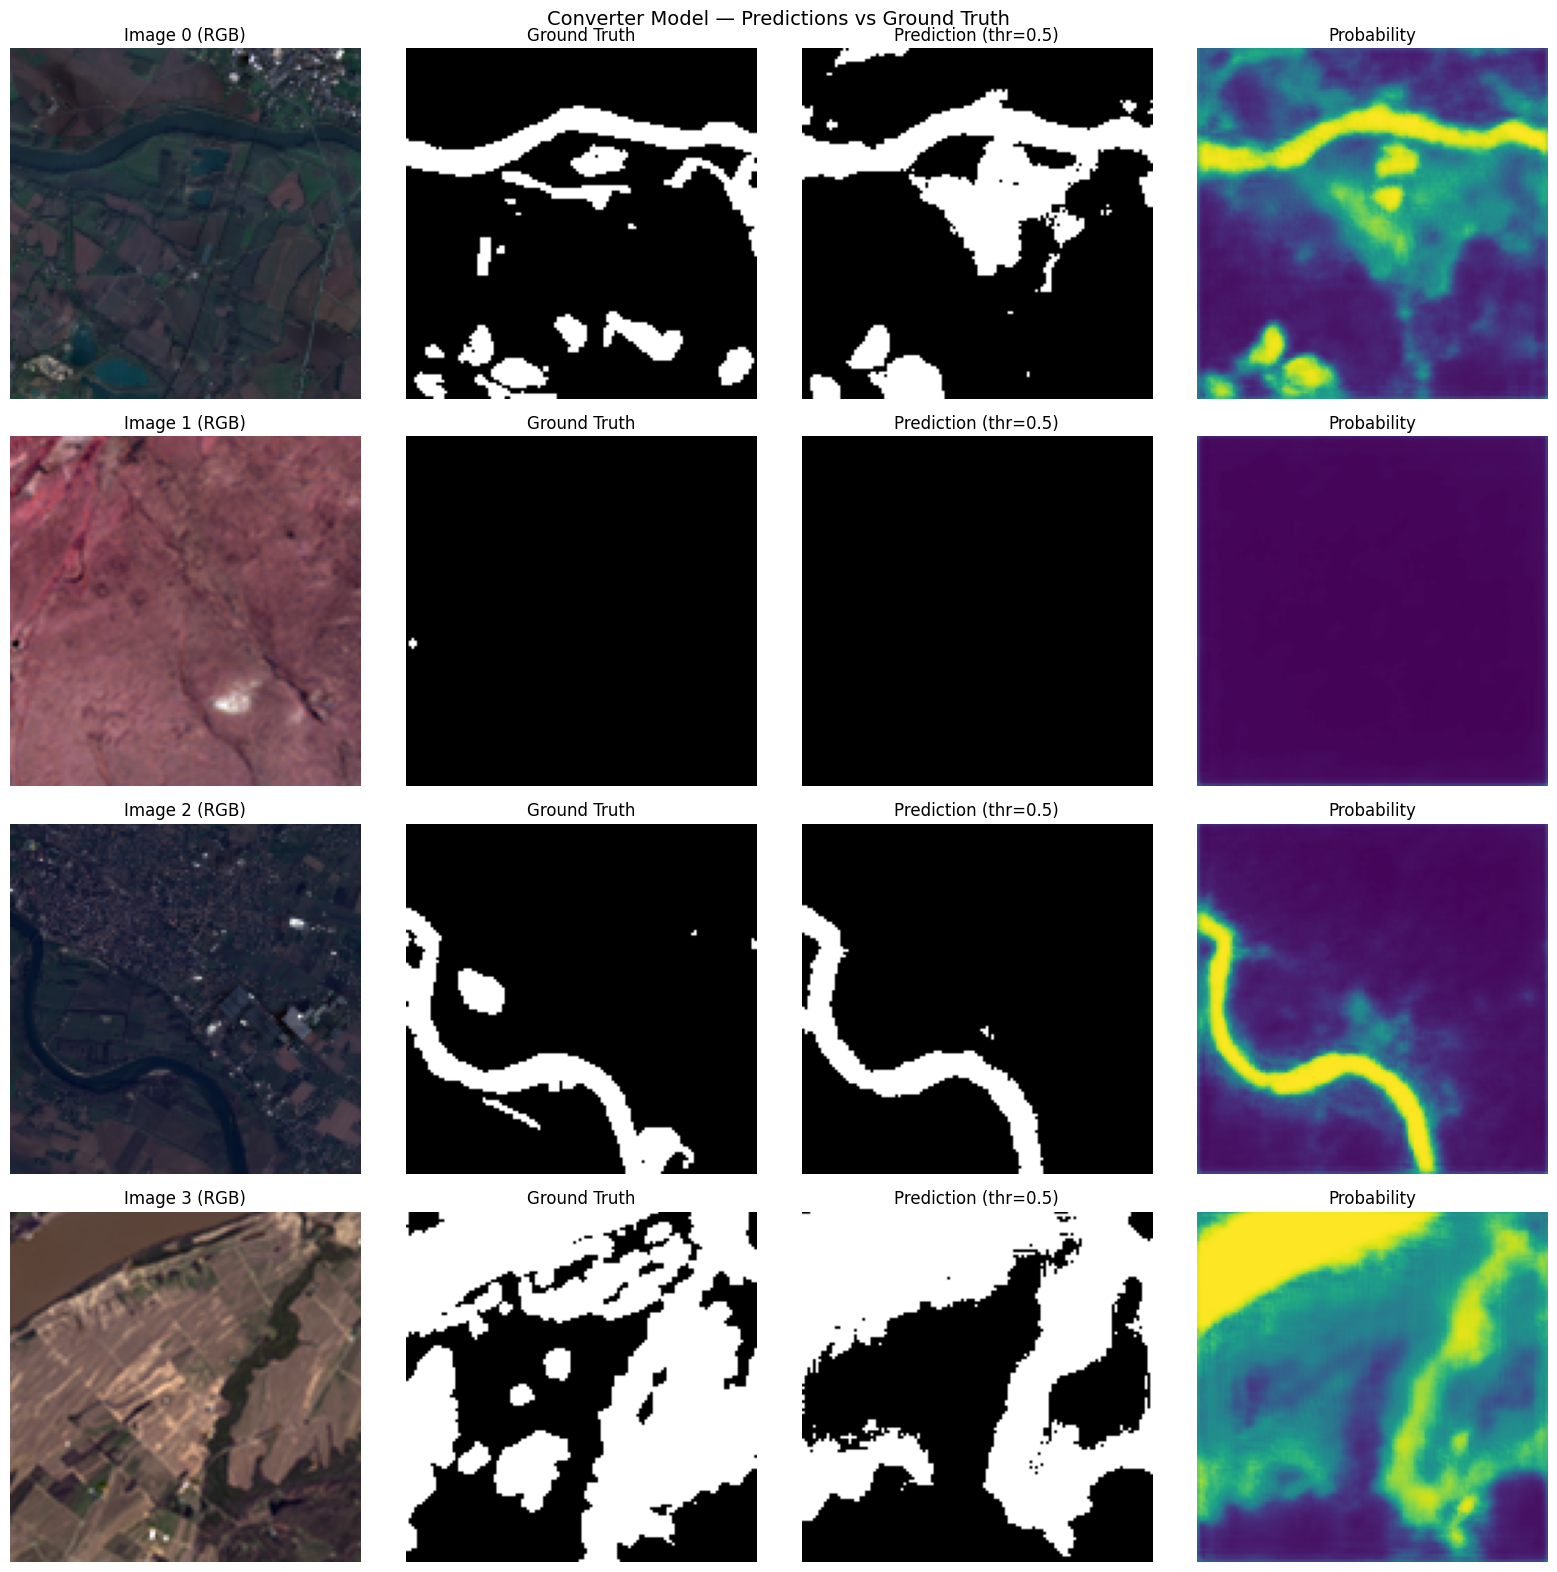

In [26]:
@torch.no_grad()
def predict_batch(model, loader, n=4):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    logits = model(x)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    return x.cpu(), y.cpu(), preds.cpu(), probs.cpu()

x_vis, y_vis, p_vis, prob_vis = predict_batch(model, test_loader, n=4)
n_show = min(4, x_vis.size(0))

fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
if n_show == 1:
    axes = axes[None, :]

for i in range(n_show):
    rgb = x_vis[i, [3, 2, 1]].numpy()
    rgb = np.stack([(b - b.min()) / (b.max() - b.min() + 1e-8) for b in rgb], axis=-1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Image {i} (RGB)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_vis[i, 0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(p_vis[i, 0], cmap="gray")
    axes[i, 2].set_title("Prediction (thr=0.5)")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(prob_vis[i, 0], cmap="viridis", vmin=0, vmax=1)
    axes[i, 3].set_title("Probability")
    axes[i, 3].axis("off")

plt.suptitle("Converter Model — Predictions vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
config = {
    "architecture": "CNNConverter + SMP Unet ResNet34",
    "converter": {
        "in_channels": NUM_CHANNELS,
        "out_channels": 3,
        "base_channels": 32,
    },
    "segmenter": {
        "encoder_name": "resnet34",
        "encoder_weights": "imagenet",
        "in_channels": 3,
        "classes": 1,
    },
    "norm_channels": NORM_CHANNELS,
    "exclude_from_norm": EXCLUDE_FROM_NORM,
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "threshold": 0.5,
    "best_epoch": best_epoch,
    "best_val_iou": float(best_val_iou),
    "test_metrics": {
        "loss": float(test_loss),
        "accuracy": float(test_m["accuracy"]),
        "precision": float(test_m["precision"]),
        "recall": float(test_m["recall"]),
        "f1": float(test_m["f1"]),
        "iou": float(test_m["iou"]),
    },
}

config_path = DATASET_DIR / "converter_unet_config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Checkpoint:", best_path)
print("Config:    ", config_path)

Checkpoint: /content/drive/MyDrive/Cellula/WaterSegmentation/data/best_converter_unet.pth
Config:     /content/drive/MyDrive/Cellula/WaterSegmentation/data/converter_unet_config.json
